In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


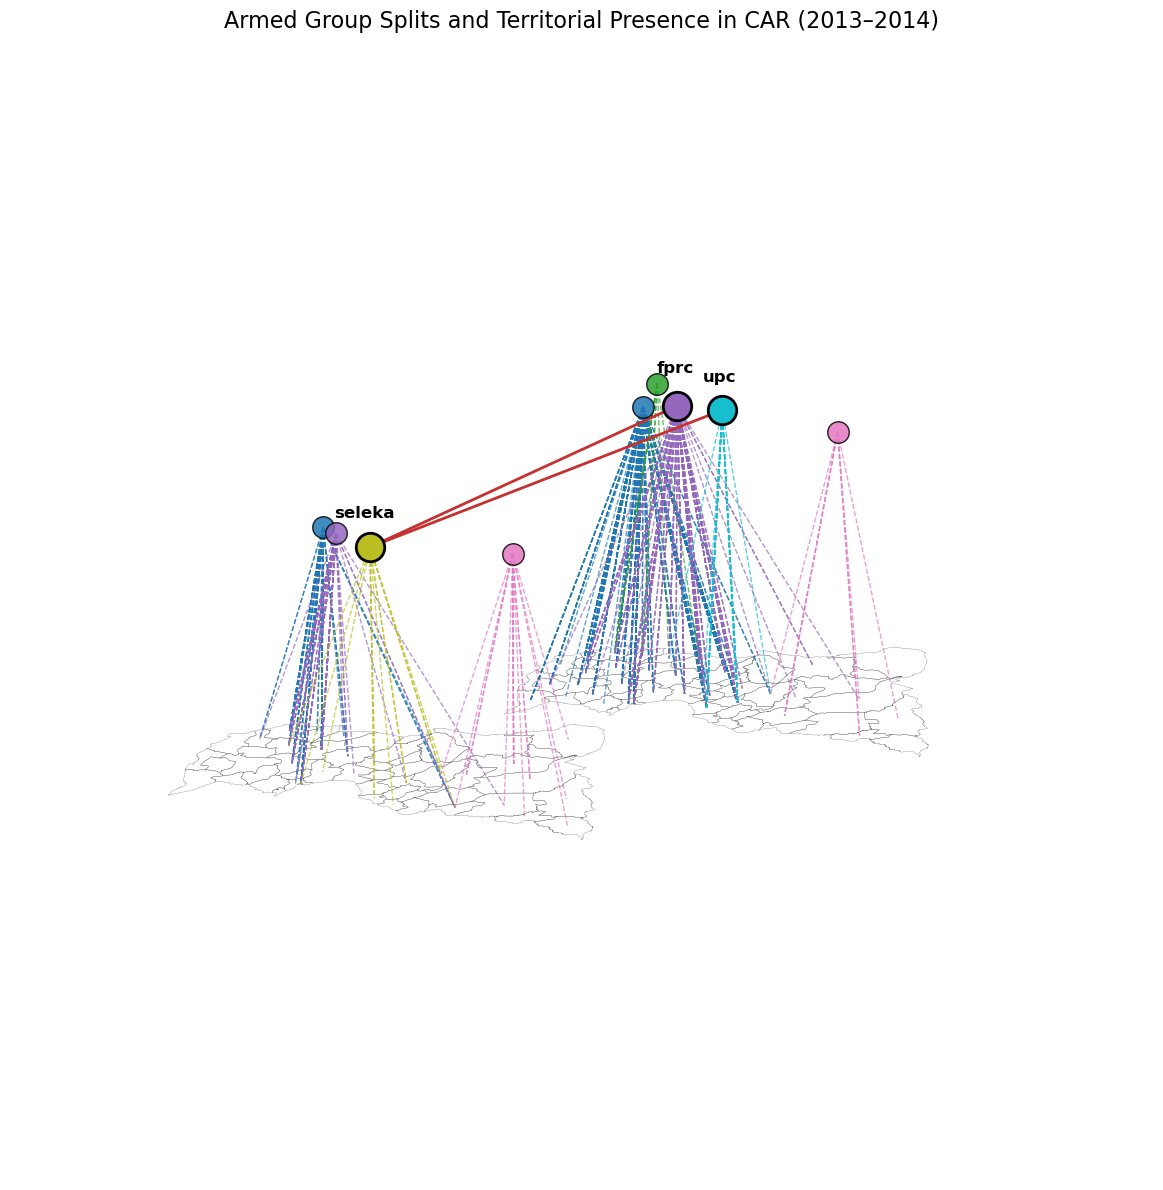

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")
actors = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv")
gadm = gpd.read_file("/Users/samqiu/Desktop/triad_datacollecting-main/car_adm2.shp")

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
for col in ["group_A", "group_B"]:
    dyads[col] = dyads[col].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()
gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

dyads["split_month"] = pd.to_datetime(dyads["split_month"])
dyads["split_year"] = dyads["split_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"])
actors["ed"] = pd.to_datetime(actors["ed"])
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

df13 = active_actors_year(actors, year_1)
df14 = active_actors_year(actors, year_2)

splits_2014 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()

# ---------------------------------------------------
# LABEL ONLY ACTORS WITH SPLIT RECORDS (AUTO)
#   parents labeled on 2013 layer; children labeled on 2014 layer
# ---------------------------------------------------
split_parents = set(splits_2014["group_A"].dropna().astype(str).str.strip().str.lower())
split_children = set(splits_2014["group_B"].dropna().astype(str).str.strip().str.lower())

# ---------------------------------------------------
# NORMALIZE MAP GEOMETRY
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom(geom, target_width=40.0):
    width = maxx - minx
    if width == 0:
        return geom
    scale = target_width / width
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(normalize_geom)

# ---------------------------------------------------
# REPROJECT FOR SAFE CENTROID
# ---------------------------------------------------
if gadm.crs is not None and gadm.crs.is_geographic:
    gadm_proj = gadm.to_crs(epsg=3857)
else:
    gadm_proj = gadm.copy()

gadm_proj["centroid"] = gadm_proj.geometry.centroid
gadm["centroid"] = (
    gadm_proj.set_geometry("centroid")
            .to_crs(gadm.crs)["centroid"]
)

# ---------------------------------------------------
# ACTOR POSITIONS (MEAN CENTROID)
# ---------------------------------------------------
def compute_actor_positions(df_year, xoff=0.0, yoff=0.0):
    positions = {}
    for actor in df_year["actor"].unique():
        locs = df_year[df_year["actor"] == actor]["NAME_2"]
        centroids = gadm[gadm["NAME_2"].isin(locs)]["centroid"]
        if len(centroids) == 0:
            continue
        x_mean = centroids.x.mean() + xoff
        y_mean = centroids.y.mean() + yoff
        positions[actor] = (x_mean, y_mean)
    return positions

x_shift = 18.0
y_shift = 18.0

pos13 = compute_actor_positions(df13)
pos14 = compute_actor_positions(df14, xoff=x_shift, yoff=y_shift)

# now that positions exist, restrict highlights to plotted actors
highlight_2013 = split_parents.intersection(pos13.keys())
highlight_2014 = split_children.intersection(pos14.keys())

# ---------------------------------------------------
# COLORS
# ---------------------------------------------------
all_groups = sorted(set(list(pos13.keys()) + list(pos14.keys())))
base_colors = plt.cm.tab10(np.linspace(0, 1, len(all_groups)))
actor_colors = {g: base_colors[i] for i, g in enumerate(all_groups)}

# ---------------------------------------------------
# 3D FIGURE
# ---------------------------------------------------
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection="3d")

z_map_2013 = 0.0
z_platform_2013 = 1
z_map_2014 = 0.2
z_platform_2014 = 1.4

# ---------------------------------------------------
# PLOT MAP
# ---------------------------------------------------
def plot_map_layer(gdf, z_level, xoff=0.0, yoff=0.0):
    for geom in gdf.geometry:
        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)
        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color="black", linewidth=0.25, alpha=0.5)
        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color="black", linewidth=0.25, alpha=0.5)

plot_map_layer(gadm, z_map_2013)
plot_map_layer(gadm, z_map_2014, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# PLOT ACTORS (LABEL ONLY SPLIT ACTORS)
# ---------------------------------------------------
def radial_offsets(n, radius=0.6):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return [(radius * np.cos(a), radius * np.sin(a)) for a in angles]

# ---------- 2013 ----------
actors_13 = list(pos13.items())
offsets_13 = radial_offsets(len(actors_13))

for ((actor, (x, y)), (dx, dy)) in zip(actors_13, offsets_13):
    is_highlight = actor in highlight_2013

    ax.scatter(
        x, y, z_platform_2013,
        s=420 if is_highlight else 240,
        color=actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    if is_highlight:
        ax.text(
            x + dx,
            y + dy,
            z_platform_2013 + 0.15,
            actor,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )

# ---------- 2014 ----------
actors_14 = list(pos14.items())
offsets_14 = radial_offsets(len(actors_14))

for ((actor, (x, y)), (dx, dy)) in zip(actors_14, offsets_14):
    is_highlight = actor in highlight_2014

    ax.scatter(
        x, y, z_platform_2014,
        s=420 if is_highlight else 240,
        color=actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    if is_highlight:
        ax.text(
            x + dx,
            y + dy,
            z_platform_2014 + 0.15,
            actor,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )

# ---------------------------------------------------
# ACTOR → EACH LOCATION (DASHED)
# ---------------------------------------------------
def link_actor_to_each_location(df_year, pos_dict,
                                z_platform, z_map,
                                actor_xoff=0.0, actor_yoff=0.0,
                                map_xoff=0.0, map_yoff=0.0):

    for actor in df_year["actor"].unique():
        if actor not in pos_dict:
            continue

        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        locs = df_year[df_year["actor"] == actor]["NAME_2"]

        for loc in locs:
            sub = gadm[gadm["NAME_2"] == loc]
            if sub.empty:
                continue

            centroid = sub["centroid"].iloc[0]
            centroid = affinity.translate(centroid, xoff=map_xoff, yoff=map_yoff)

            ax.plot([x_actor, centroid.x],
                    [y_actor, centroid.y],
                    [z_platform, z_map],
                    color=actor_colors[actor],
                    linewidth=1.0,
                    alpha=0.7,
                    linestyle="dashed")

link_actor_to_each_location(df13, pos13,
                            z_platform_2013, z_map_2013)

link_actor_to_each_location(df14, pos14,
                            z_platform_2014, z_map_2014,
                            map_xoff=x_shift,
                            map_yoff=y_shift)

# ---------------------------------------------------
# SPLIT LINKS
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row["group_A"]
    child = row["group_B"]

    if parent in pos13 and child in pos14:
        x1, y1 = pos13[parent]
        x2, y2 = pos14[child]

        ax.plot([x1, x2],
                [y1, y2],
                [z_platform_2013, z_platform_2014],
                color="#c53030", linewidth=2)

# ---------------------------------------------------
# CLEAN VISUAL
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.5])

plt.title("Armed Group Splits and Territorial Presence in CAR (2013–2014)",
          fontsize=16)
plt.tight_layout()
plt.savefig(
    "/Users/samqiu/Desktop/triad_datacollecting-main/splits_car_1314.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# PATHS
# ---------------------------------------------------
BASE_DIR = "/Users/samqiu/Desktop/triad_datacollecting-main"
DYADS_PATH = os.path.join(BASE_DIR, "car_parent_child.csv")
ACTORS_PATH = os.path.join(BASE_DIR, "car_actors.csv")
GADM_PATH = os.path.join(BASE_DIR, "car_adm2.shp")

OUT_DIR = os.path.join(BASE_DIR, "year_snapshots")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv(DYADS_PATH)
actors = pd.read_csv(ACTORS_PATH)
gadm = gpd.read_file(GADM_PATH)

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
for col in ["group_A", "group_B"]:
    dyads[col] = dyads[col].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()
gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

# Split timing
dyads["split_month"] = pd.to_datetime(dyads["split_month"], errors="coerce")
dyads["split_year"] = dyads["split_month"].dt.year

# Merge timing (YOUR VARIABLE NAMES)
dyads["merge_month"] = pd.to_datetime(dyads["merge_month"], errors="coerce")
dyads["merge_year"] = dyads["merge_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"], errors="coerce")
actors["ed"] = pd.to_datetime(actors["ed"], errors="coerce")
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

# ---------------------------------------------------
# NORMALIZE MAP GEOMETRY (ONCE)
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom(geom, target_width=40.0):
    width = maxx - minx
    if width == 0:
        return geom
    scale = target_width / width
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(normalize_geom)

# ---------------------------------------------------
# REPROJECT FOR SAFE CENTROID (ONCE)
# ---------------------------------------------------
if gadm.crs is not None and gadm.crs.is_geographic:
    gadm_proj = gadm.to_crs(epsg=3857)
else:
    gadm_proj = gadm.copy()

gadm_proj["centroid"] = gadm_proj.geometry.centroid
gadm["centroid"] = (
    gadm_proj.set_geometry("centroid")
            .to_crs(gadm.crs)["centroid"]
)

# ---------------------------------------------------
# ACTOR POSITIONS (MEAN CENTROID)
# ---------------------------------------------------
def compute_actor_positions(df_year, xoff=0.0, yoff=0.0):
    positions = {}
    for actor in df_year["actor"].unique():
        locs = df_year[df_year["actor"] == actor]["NAME_2"]
        centroids = gadm[gadm["NAME_2"].isin(locs)]["centroid"]
        if len(centroids) == 0:
            continue
        x_mean = centroids.x.mean() + xoff
        y_mean = centroids.y.mean() + yoff
        positions[actor] = (x_mean, y_mean)
    return positions

# ---------------------------------------------------
# DRAW HELPERS
# ---------------------------------------------------
def plot_map_layer(ax, gdf, z_level, xoff=0.0, yoff=0.0):
    for geom in gdf.geometry:
        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)
        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color="black", linewidth=0.25, alpha=0.5)
        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color="black", linewidth=0.25, alpha=0.5)

def radial_offsets(n, radius=0.6):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return [(radius * np.cos(a), radius * np.sin(a)) for a in angles]

def link_actor_to_each_location(ax, df_year, pos_dict,
                                z_platform, z_map,
                                actor_colors,
                                actor_xoff=0.0, actor_yoff=0.0,
                                map_xoff=0.0, map_yoff=0.0):
    for actor in df_year["actor"].unique():
        if actor not in pos_dict:
            continue

        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        locs = df_year[df_year["actor"] == actor]["NAME_2"]
        for loc in locs:
            sub = gadm[gadm["NAME_2"] == loc]
            if sub.empty:
                continue

            centroid = sub["centroid"].iloc[0]
            centroid = affinity.translate(centroid, xoff=map_xoff, yoff=map_yoff)

            ax.plot([x_actor, centroid.x],
                    [y_actor, centroid.y],
                    [z_platform, z_map],
                    color=actor_colors[actor],
                    linewidth=1.0,
                    alpha=0.7,
                    linestyle="dashed")

# ---------------------------------------------------
# PARAMETERS (MATCH YOUR CURRENT LOOK)
# ---------------------------------------------------
x_shift = 18.0
y_shift = 18.0

z_map_1 = 0.0
z_platform_1 = 1.0
z_map_2 = 0.2
z_platform_2 = 1.4

SPLIT_LINE_COLOR = "#c53030"   # red
MERGE_LINE_COLOR = "#2f855a"   # green

# ---------------------------------------------------
# LOOP OVER YEAR PAIRS: 2010–2011 ... 2020–2021
# ---------------------------------------------------
for year_1 in range(2010, 2021):
    year_2 = year_1 + 1
    tag = f"{str(year_1)[-2:]}{str(year_2)[-2:]}"

    # active actors each year
    df1 = active_actors_year(actors, year_1)
    df2 = active_actors_year(actors, year_2)

    # splits & merges that occurred in year_2 (same logic as your split plot)
    splits_y2 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()
    merges_y2 = dyads[(dyads["merge"] == 1) & (dyads["merge_year"] == year_2)].copy()

    # parents/children sets for labeling
    split_parents = set(splits_y2["group_A"].dropna().astype(str).str.strip().str.lower())
    split_children = set(splits_y2["group_B"].dropna().astype(str).str.strip().str.lower())

    merge_parents = set(merges_y2["group_A"].dropna().astype(str).str.strip().str.lower())
    merge_children = set(merges_y2["group_B"].dropna().astype(str).str.strip().str.lower())

    # positions
    pos1 = compute_actor_positions(df1)
    pos2 = compute_actor_positions(df2, xoff=x_shift, yoff=y_shift)

    # highlight actors involved in either split or merge
    highlight_1 = (split_parents | merge_parents).intersection(pos1.keys())
    highlight_2 = (split_children | merge_children).intersection(pos2.keys())

    # colors (consistent within a snapshot)
    all_groups = sorted(set(list(pos1.keys()) + list(pos2.keys())))
    if len(all_groups) == 0:
        print(f"[skip] {year_1}-{year_2}: no actors to plot")
        continue

    base_colors = plt.cm.tab10(np.linspace(0, 1, len(all_groups)))
    actor_colors = {g: base_colors[i] for i, g in enumerate(all_groups)}

    # figure
    fig = plt.figure(figsize=(18, 12))
    ax = fig.add_subplot(111, projection="3d")

    # map layers
    plot_map_layer(ax, gadm, z_map_1)
    plot_map_layer(ax, gadm, z_map_2, xoff=x_shift, yoff=y_shift)

    # -------- year_1 actors (green outline if merger-involved, red outline if split-involved) --------
    actors_1 = list(pos1.items())
    offsets_1 = radial_offsets(len(actors_1))
    for ((actor, (x, y)), (dx, dy)) in zip(actors_1, offsets_1):
        is_split = actor in split_parents
        is_merge = actor in merge_parents
        is_highlight = (actor in highlight_1)

        # outline priority: if merge involved -> green; elif split involved -> red; else black
        if is_merge:
            edge_col, lw = MERGE_LINE_COLOR, 2.5
        elif is_split:
            edge_col, lw = SPLIT_LINE_COLOR, 2.5
        elif is_highlight:
            edge_col, lw = "black", 2.0
        else:
            edge_col, lw = "black", 1.0

        ax.scatter(
            x, y, z_platform_1,
            s=420 if is_highlight else 240,
            color=actor_colors[actor],
            edgecolor=edge_col,
            linewidth=lw,
            alpha=1.0 if is_highlight else 0.85
        )

        if is_highlight:
            ax.text(
                x + dx, y + dy, z_platform_1 + 0.15,
                actor, fontsize=12, fontweight="bold",
                ha="center", va="center"
            )

    # -------- year_2 actors --------
    actors_2 = list(pos2.items())
    offsets_2 = radial_offsets(len(actors_2))
    for ((actor, (x, y)), (dx, dy)) in zip(actors_2, offsets_2):
        is_split = actor in split_children
        is_merge = actor in merge_children
        is_highlight = (actor in highlight_2)

        if is_merge:
            edge_col, lw = MERGE_LINE_COLOR, 2.5
        elif is_split:
            edge_col, lw = SPLIT_LINE_COLOR, 2.5
        elif is_highlight:
            edge_col, lw = "black", 2.0
        else:
            edge_col, lw = "black", 1.0

        ax.scatter(
            x, y, z_platform_2,
            s=420 if is_highlight else 240,
            color=actor_colors[actor],
            edgecolor=edge_col,
            linewidth=lw,
            alpha=1.0 if is_highlight else 0.85
        )

        if is_highlight:
            ax.text(
                x + dx, y + dy, z_platform_2 + 0.15,
                actor, fontsize=12, fontweight="bold",
                ha="center", va="center"
            )

    # actor → locations (dashed)
    link_actor_to_each_location(ax, df1, pos1, z_platform_1, z_map_1, actor_colors)
    link_actor_to_each_location(ax, df2, pos2, z_platform_2, z_map_2, actor_colors,
                                map_xoff=x_shift, map_yoff=y_shift)

    # -------- split links (red) --------
    for _, row in splits_y2.iterrows():
        parent = row["group_A"]
        child = row["group_B"]
        if parent in pos1 and child in pos2:
            x1, y1 = pos1[parent]
            x2, y2 = pos2[child]
            ax.plot([x1, x2], [y1, y2], [z_platform_1, z_platform_2],
                    color=SPLIT_LINE_COLOR, linewidth=2)

    # -------- merge links (green) --------
    for _, row in merges_y2.iterrows():
        parent = row["group_A"]
        child = row["group_B"]
        if parent in pos1 and child in pos2:
            x1, y1 = pos1[parent]
            x2, y2 = pos2[child]
            ax.plot([x1, x2], [y1, y2], [z_platform_1, z_platform_2],
                    color=MERGE_LINE_COLOR, linewidth=2)

    # finalize + save
    ax.set_axis_off()
    ax.view_init(elev=18, azim=-55)
    ax.set_box_aspect([1, 1, 0.5])

    plt.title(f"Armed Group Splits (red) & Merges (green) in CAR ({year_1}–{year_2})",
              fontsize=16)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"splits_merges_car_{tag}.png")
    plt.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.close(fig)

    print(f"[saved] {out_path}")

[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1011.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1112.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1213.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1314.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1415.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1516.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1617.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1718.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1819.png
[saved] /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_car_1920.png
[saved] /Users/samqi

In [18]:
# In a Jupyter notebook cell:
# This will (1) find all your saved PNGs, (2) build a scroll/slider viewer,
# (3) optionally write a standalone HTML you can open or embed in a knitted HTML.

import os
import re
import base64
from pathlib import Path
from IPython.display import HTML, IFrame, display

# ---------------------------------------------------
# CONFIG: folder where your PNGs are saved
# ---------------------------------------------------
BASE_DIR = "/Users/samqiu/Desktop/triad_datacollecting-main"
OUT_DIR = os.path.join(BASE_DIR, "year_snapshots")

# If you used: splits_merges_car_1011.png ... splits_merges_car_2021.png
PATTERN = r"^splits_merges_car_(\d{4})\.png$"   # captures "1011", "1112", ..., "2021"

# ---------------------------------------------------
# Collect files
# ---------------------------------------------------
png_files = []
for fn in os.listdir(OUT_DIR):
    m = re.match(PATTERN, fn)
    if m:
        tag = m.group(1)
        png_files.append((tag, os.path.join(OUT_DIR, fn)))

# sort by starting year (tag "1011" -> 2010)
def tag_to_start_year(tag):
    # "1011" -> 2010; assumes 2010–2021 range
    return 2000 + int(tag[:2])

png_files = sorted(png_files, key=lambda x: tag_to_start_year(x[0]))

if len(png_files) == 0:
    raise FileNotFoundError(f"No files matched {PATTERN} in {OUT_DIR}")

tags = [t for (t, _) in png_files]
paths = [p for (_, p) in png_files]

# ---------------------------------------------------
# Helper: embed PNGs as base64 so it works in ipynb AND knitted HTML
# ---------------------------------------------------
def png_to_data_uri(path):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")
    return "data:image/png;base64," + b64

data_uris = [png_to_data_uri(p) for p in paths]

# Build labels like "2010–2011"
labels = [f"{tag_to_start_year(t)}–{tag_to_start_year(t)+1}" for t in tags]

# ---------------------------------------------------
# Build interactive HTML viewer (slider + buttons + keyboard support)
# ---------------------------------------------------
html = f"""
<div style="max-width:1100px;margin:0 auto;">
  <div style="display:flex;align-items:center;gap:12px;flex-wrap:wrap;">
    <h3 style="margin:0;">CAR Splits (red) & Merges (green): Year Viewer</h3>
    <div style="margin-left:auto;display:flex;gap:8px;">
      <button id="prevBtn" style="padding:6px 10px;">◀ Prev</button>
      <button id="nextBtn" style="padding:6px 10px;">Next ▶</button>
    </div>
  </div>

  <div style="margin:10px 0;">
    <input type="range" min="0" max="{len(data_uris)-1}" value="0" step="1"
           id="yearSlider" style="width:100%;">
    <div id="yearLabel" style="font-weight:700;margin-top:6px;">{labels[0]}</div>
  </div>

  <img id="snapshot"
       src="{data_uris[0]}"
       style="width:100%;border:1px solid #ccc;border-radius:10px;box-shadow:0 2px 10px rgba(0,0,0,0.08);">

  <div style="margin-top:8px;color:#555;font-size:13px;">
    Tip: use left/right arrow keys to move between years.
  </div>
</div>

<script>
  const uris = {data_uris};
  const labels = {labels};

  const slider = document.getElementById("yearSlider");
  const img = document.getElementById("snapshot");
  const label = document.getElementById("yearLabel");
  const prevBtn = document.getElementById("prevBtn");
  const nextBtn = document.getElementById("nextBtn");

  function render(i) {{
    slider.value = i;
    img.src = uris[i];
    label.textContent = labels[i];
  }}

  slider.addEventListener("input", () => {{
    render(parseInt(slider.value));
  }});

  prevBtn.addEventListener("click", () => {{
    let i = parseInt(slider.value) - 1;
    if (i < 0) i = 0;
    render(i);
  }});

  nextBtn.addEventListener("click", () => {{
    let i = parseInt(slider.value) + 1;
    if (i > uris.length - 1) i = uris.length - 1;
    render(i);
  }});

  document.addEventListener("keydown", (e) => {{
    if (e.key === "ArrowLeft") prevBtn.click();
    if (e.key === "ArrowRight") nextBtn.click();
  }});
</script>
"""

#display(HTML(html))

# ---------------------------------------------------
# OPTIONAL: write a standalone HTML file (for knitted HTML / sharing)
# ---------------------------------------------------
viewer_path = os.path.join(OUT_DIR, "splits_merges_viewer_2010_2021.html")
with open(viewer_path, "w", encoding="utf-8") as f:
    f.write("<!doctype html><html><head><meta charset='utf-8'>"
            "<meta name='viewport' content='width=device-width, initial-scale=1'>"
            "<title>CAR Splits & Merges Viewer</title></head><body>")
    f.write(html)
    f.write("</body></html>")

print("Saved standalone viewer HTML to:", viewer_path)

# In-notebook embed (works nicely in Jupyter):
display(IFrame(viewer_path, width="850", height="600"))

Saved standalone viewer HTML to: /Users/samqiu/Desktop/triad_datacollecting-main/year_snapshots/splits_merges_viewer_2010_2021.html
